
<div style="padding: 28px 32px; border-radius: 18px; background: linear-gradient(135deg, #0f172a 0%, #1d4ed8 45%, #38bdf8 100%); color: white; box-shadow: 0 20px 50px rgba(15, 23, 42, 0.18);">
  <p style="margin: 0; font-size: 14px; letter-spacing: 0.18em; text-transform: uppercase; opacity: 0.85;">Customer Intelligence • Revenue Forecasting System</p>
  <h1 style="margin: 12px 0 10px; font-size: 34px;">Exploratory Data Analysis</h1>
  <p style="margin: 0; font-size: 17px; max-width: 820px; line-height: 1.7;">
    This notebook turns the cleaned Superstore dataset into an executive-ready story: how revenue behaves over time,
    where profit concentrates, which products and customers drive performance, and where losses need attention.
  </p>
</div>

<br>


In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import HTML, display
from matplotlib.ticker import FuncFormatter

pd.options.display.float_format = "{:,.2f}".format

sns.set_theme(
    style="whitegrid",
    context="talk",
    palette="crest",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.facecolor": "#f8fafc",
        "figure.facecolor": "white",
        "grid.color": "#dbe4f0",
    },
)

COLORS = {
    "navy": "#0f172a",
    "blue": "#2563eb",
    "cyan": "#06b6d4",
    "green": "#16a34a",
    "amber": "#f59e0b",
    "red": "#dc2626",
    "slate": "#475569",
    "sky": "#38bdf8",
}


def currency(x, pos=None):
    return f"${x:,.0f}"


def percent(x, pos=None):
    return f"{x:.0%}"


def add_value_labels(ax, fmt="number"):
    for patch in ax.patches:
        value = patch.get_width() if ax.get_xlim()[1] > ax.get_ylim()[1] else patch.get_height()
        if fmt == "currency":
            label = f"${value:,.0f}"
        elif fmt == "percent":
            label = f"{value:.1%}"
        else:
            label = f"{value:,.0f}"

        if hasattr(patch, "get_width") and patch.get_width() > 0 and patch.get_height() > 0:
            if patch.get_width() > patch.get_height():
                ax.text(
                    patch.get_width(),
                    patch.get_y() + patch.get_height() / 2,
                    f"  {label}",
                    va="center",
                    fontsize=11,
                    color=COLORS["navy"],
                )
            else:
                ax.text(
                    patch.get_x() + patch.get_width() / 2,
                    patch.get_height(),
                    label,
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    color=COLORS["navy"],
                )


def render_kpis(metrics):
    cards = []
    for title, value, accent in metrics:
        cards.append(
            f'''
            <div style="flex: 1; min-width: 200px; background: white; border: 1px solid #e2e8f0; border-top: 5px solid {accent};
                        border-radius: 18px; padding: 18px 20px; box-shadow: 0 10px 25px rgba(15, 23, 42, 0.06);">
                <div style="font-size: 13px; text-transform: uppercase; letter-spacing: 0.08em; color: #64748b;">{title}</div>
                <div style="margin-top: 8px; font-size: 28px; font-weight: 700; color: #0f172a;">{value}</div>
            </div>
            '''
        )
    display(
        HTML(
            '<div style="display: flex; gap: 16px; flex-wrap: wrap; margin: 8px 0 18px;">'
            + "".join(cards)
            + "</div>"
        )
    )


In [2]:

df = pd.read_csv("../data/cleaned/superstore_cleaned.csv")

df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])
df["order_month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()
df["profit_margin"] = np.where(df["sales"] != 0, df["profit"] / df["sales"], 0)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
df.head()


Dataset shape: 51,290 rows x 27 columns


,category,city,country,customer_id,customer_name,discount,market,order_date,order_id,order_priority,...,ship_date,ship_mode,shipping_cost,state,sub_category,order_year,order_month,order_day,month_name,profit_margin
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.00,US,2011-01-07,CA-2011-130813,High,...,2011-01-09,Second Class,4.37,California,Paper,2011,2011-01-01,7,January,0.49
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.00,US,2011-01-21,CA-2011-148614,Medium,...,2011-01-26,Standard Class,0.94,California,Paper,2011,2011-01-01,21,January,0.49
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.00,US,2011-08-05,CA-2011-118962,Medium,...,2011-08-09,Standard Class,1.81,California,Paper,2011,2011-08-01,5,August,0.47
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.00,US,2011-08-05,CA-2011-118962,Medium,...,2011-08-09,Standard Class,4.59,California,Paper,2011,2011-08-01,5,August,0.48
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.00,US,2011-09-29,CA-2011-146969,High,...,2011-10-03,Standard Class,1.32,California,Paper,2011,2011-09-01,29,September,0.52



## Executive Snapshot

This section answers the first leadership question quickly: how large the business is, how healthy profitability looks, and what the customer base contributes on average.


In [3]:

total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
avg_order_value = total_sales / total_orders
avg_profit_margin = total_profit / total_sales

render_kpis(
    [
        ("Total Sales", f"${total_sales:,.0f}", COLORS["blue"]),
        ("Total Profit", f"${total_profit:,.0f}", COLORS["green"]),
        ("Unique Orders", f"{total_orders:,}", COLORS["cyan"]),
        ("Customers", f"{total_customers:,}", COLORS["amber"]),
    ]
)

snapshot = pd.DataFrame(
    {
        "Metric": [
            "Average Order Value",
            "Average Revenue per Customer",
            "Average Profit per Order",
            "Overall Profit Margin",
        ],
        "Value": [
            f"${avg_order_value:,.2f}",
            f"${(total_sales / total_customers):,.2f}",
            f"${(total_profit / total_orders):,.2f}",
            f"{avg_profit_margin:.2%}",
        ],
    }
)

display(
    snapshot.style.hide(axis="index")
    .set_properties(**{"background-color": "#f8fafc", "color": "#0f172a"})
    .set_table_styles(
        [
            {"selector": "th", "props": [("background-color", "#dbeafe"), ("color", "#0f172a")]},
            {"selector": "td", "props": [("border", "1px solid #e2e8f0")]},
        ]
    )
)


Metric,Value
Average Order Value,$505.01
Average Revenue per Customer,"$2,594.48"
Average Profit per Order,$58.62
Overall Profit Margin,11.61%



> **Insight:** The business already operates at multi-million dollar scale, but the more useful takeaway is efficiency: average order value and overall margin provide a fast benchmark for evaluating whether future segment, product, or regional patterns are strong enough to scale.



## Time Intelligence

Trend analysis helps answer whether growth is steady, seasonal, or fragile. To make the patterns easier to read, the charts below combine the raw monthly values with a 3-month rolling average.


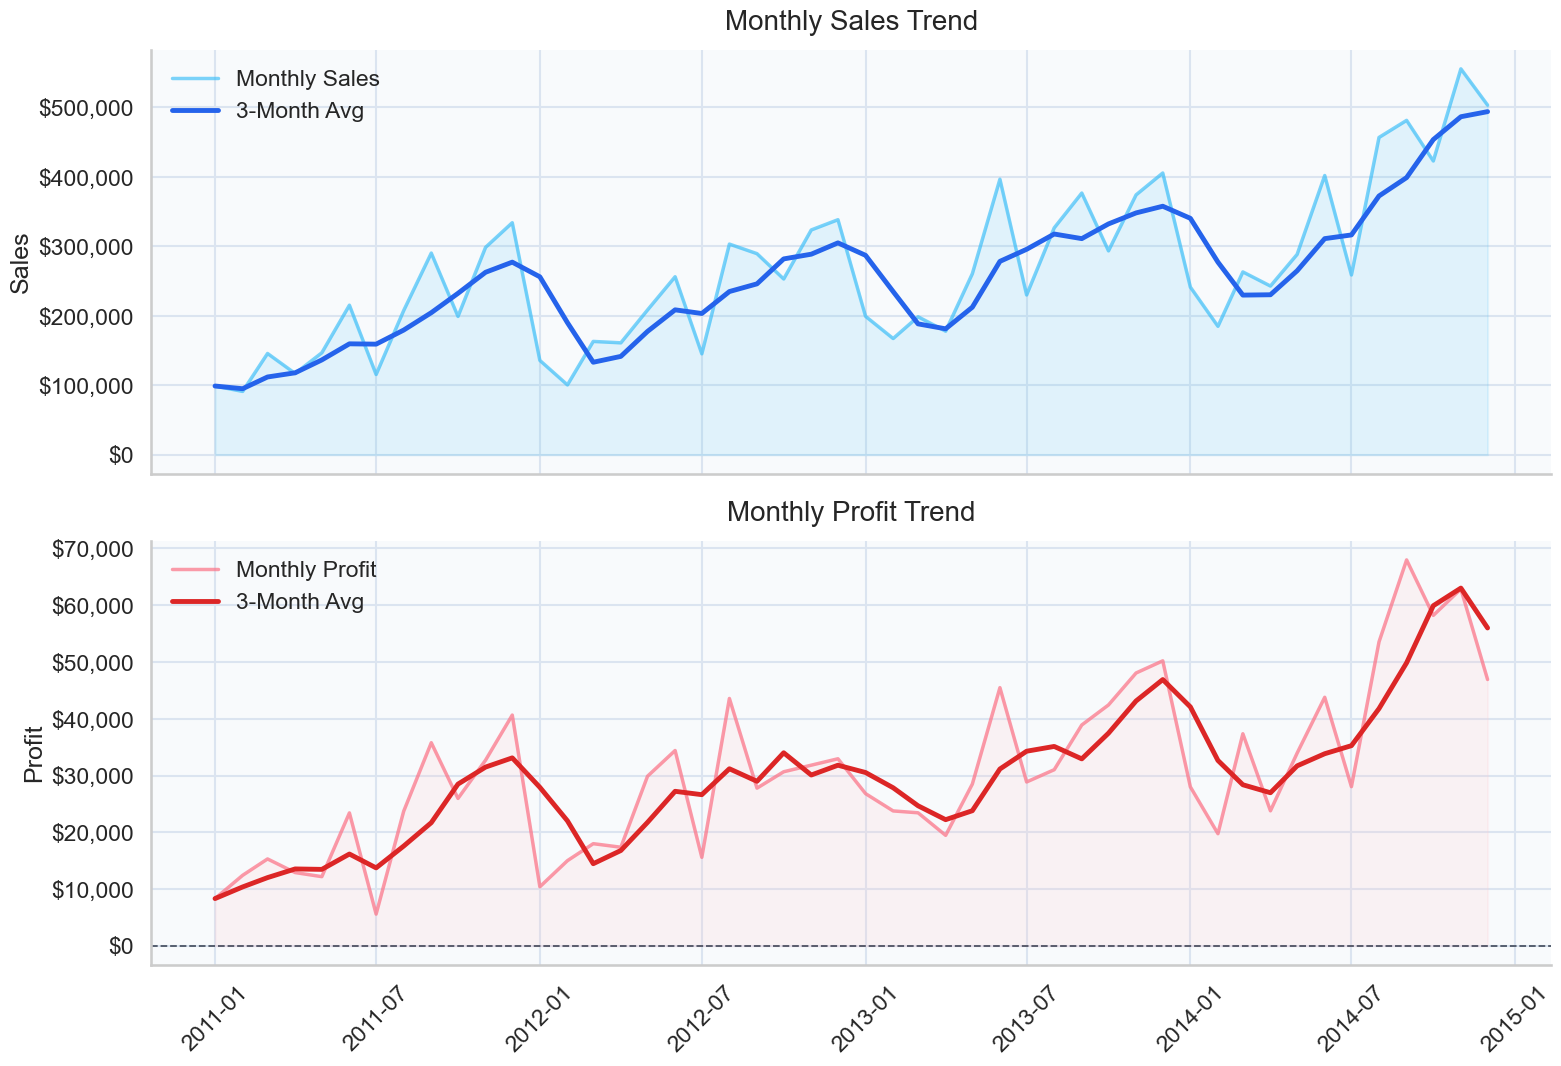

In [4]:

monthly = (
    df.groupby("order_month")[["sales", "profit"]]
    .sum()
    .assign(
        sales_ma=lambda x: x["sales"].rolling(3, min_periods=1).mean(),
        profit_ma=lambda x: x["profit"].rolling(3, min_periods=1).mean(),
    )
)

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)

axes[0].plot(monthly.index, monthly["sales"], color=COLORS["sky"], linewidth=2.5, alpha=0.65, label="Monthly Sales")
axes[0].plot(monthly.index, monthly["sales_ma"], color=COLORS["blue"], linewidth=3.5, label="3-Month Avg")
axes[0].fill_between(monthly.index, monthly["sales"], color=COLORS["sky"], alpha=0.12)
axes[0].set_title("Monthly Sales Trend", fontsize=20, pad=14)
axes[0].set_ylabel("Sales")
axes[0].yaxis.set_major_formatter(FuncFormatter(currency))
axes[0].legend(frameon=False)

axes[1].plot(monthly.index, monthly["profit"], color="#fb7185", linewidth=2.5, alpha=0.7, label="Monthly Profit")
axes[1].plot(monthly.index, monthly["profit_ma"], color=COLORS["red"], linewidth=3.5, label="3-Month Avg")
axes[1].axhline(0, color=COLORS["navy"], linewidth=1.3, linestyle="--", alpha=0.7)
axes[1].fill_between(monthly.index, monthly["profit"], color="#fecdd3", alpha=0.2)
axes[1].set_title("Monthly Profit Trend", fontsize=20, pad=14)
axes[1].set_ylabel("Profit")
axes[1].yaxis.set_major_formatter(FuncFormatter(currency))
axes[1].legend(frameon=False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



> **Insight:** Revenue volume and profitability do not always move together. Any period where sales stay strong but profit softens deserves follow-up, because it usually points to discounting pressure, product mix shifts, or rising fulfillment costs.



## Geographic Performance

Geography tells us where demand is concentrated and whether those markets are also contributing profit. Looking at sales and profit together prevents us from confusing scale with quality.


E:\python_temp\ipykernel_23356\95789230.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.values, y=country_sales.index, ax=axes[0], palette="Blues_r")


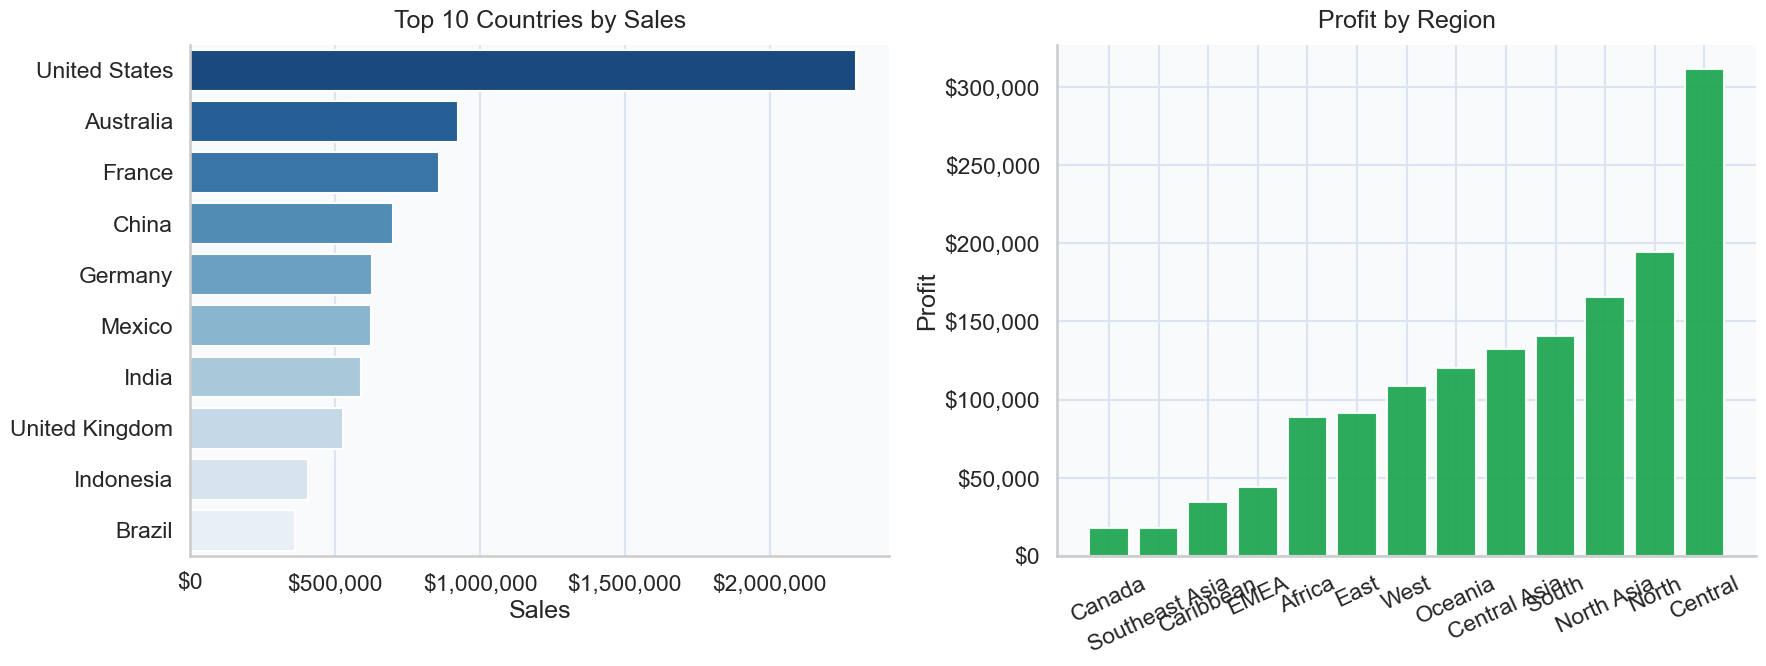

In [5]:

country_sales = df.groupby("country")["sales"].sum().sort_values(ascending=False).head(10)
region_profit = df.groupby("region")["profit"].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x=country_sales.values, y=country_sales.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 10 Countries by Sales", fontsize=18, pad=12)
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(FuncFormatter(currency))

profit_colors = [COLORS["red"] if value < 0 else COLORS["green"] for value in region_profit.values]
axes[1].bar(region_profit.index, region_profit.values, color=profit_colors, alpha=0.9)
axes[1].set_title("Profit by Region", fontsize=18, pad=12)
axes[1].set_ylabel("Profit")
axes[1].yaxis.set_major_formatter(FuncFormatter(currency))
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()



> **Insight:** The strongest commercial markets are not automatically the most profitable ones. Regions that deliver large sales with weaker profit should be treated as optimization targets rather than automatic success stories.



## Product and Category Mix

This view shows what the business sells most, what it earns most from, and which sub-categories create drag. That combination is especially useful for assortment and pricing decisions.


E:\python_temp\ipykernel_23356\6915578.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_summary.index, y=category_summary["sales"], ax=axes[0], palette="crest")
E:\python_temp\ipykernel_23356\6915578.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_summary.index, y=category_summary["profit"], ax=axes[1], palette="flare")


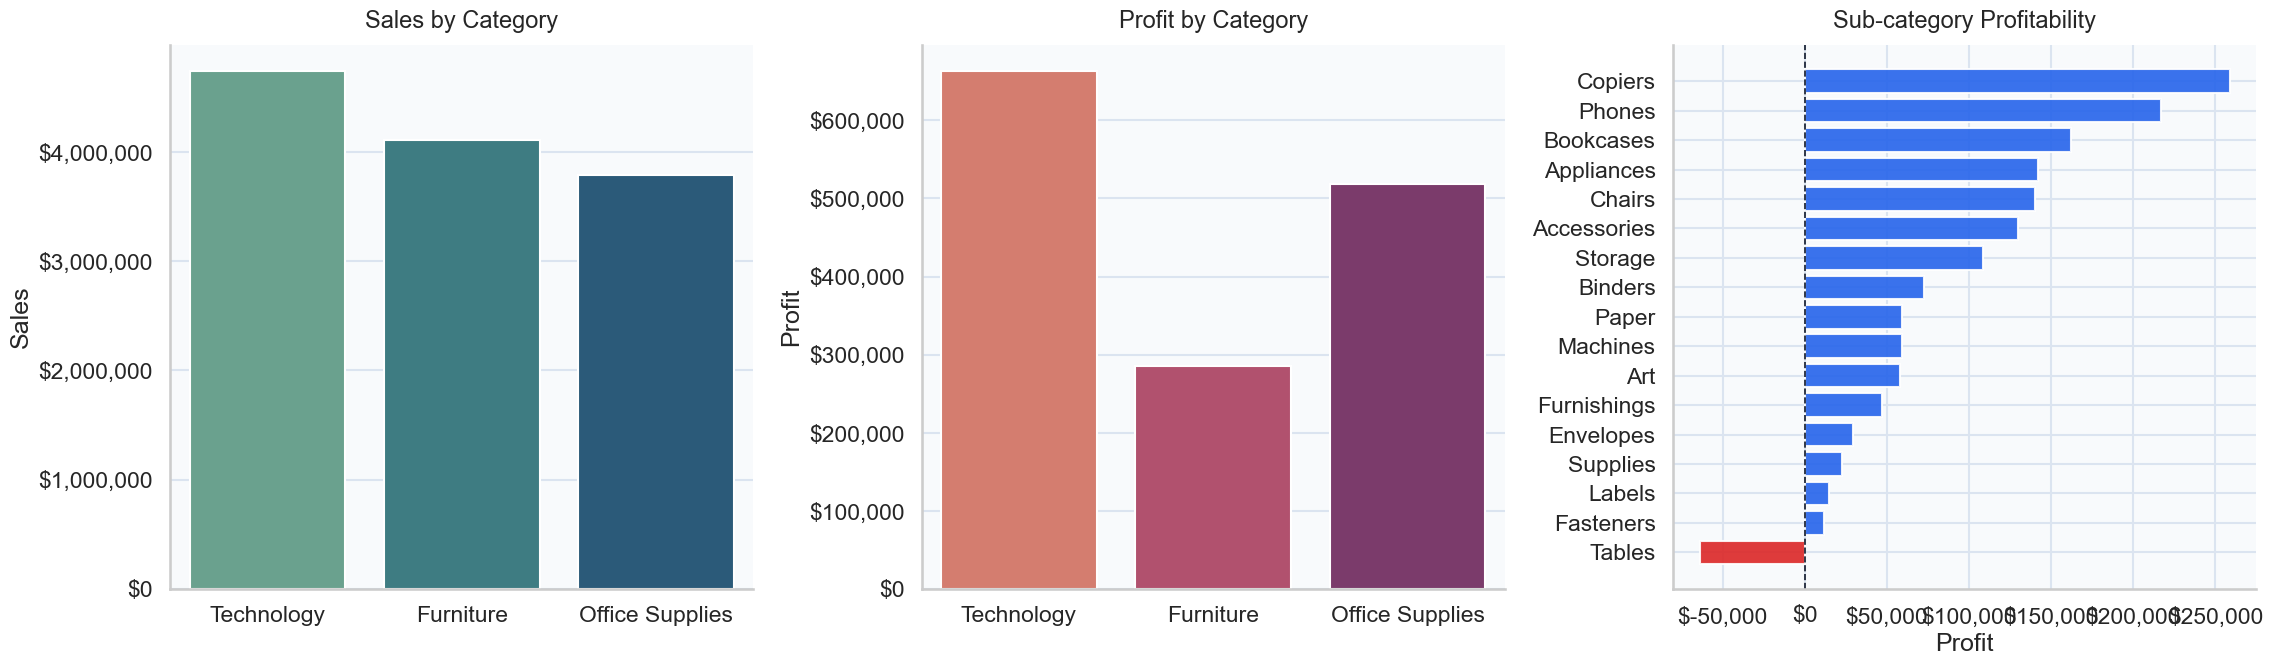

In [6]:

category_summary = (
    df.groupby("category")[["sales", "profit"]]
    .sum()
    .sort_values("sales", ascending=False)
)
subcat_profit = df.groupby("sub_category")["profit"].sum().sort_values()

fig, axes = plt.subplots(1, 3, figsize=(23, 7))

sns.barplot(x=category_summary.index, y=category_summary["sales"], ax=axes[0], palette="crest")
axes[0].set_title("Sales by Category", fontsize=17, pad=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("Sales")
axes[0].yaxis.set_major_formatter(FuncFormatter(currency))

sns.barplot(x=category_summary.index, y=category_summary["profit"], ax=axes[1], palette="flare")
axes[1].set_title("Profit by Category", fontsize=17, pad=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("Profit")
axes[1].yaxis.set_major_formatter(FuncFormatter(currency))

subcat_colors = [COLORS["red"] if value < 0 else COLORS["blue"] for value in subcat_profit.values]
axes[2].barh(subcat_profit.index, subcat_profit.values, color=subcat_colors, alpha=0.9)
axes[2].axvline(0, color=COLORS["navy"], linestyle="--", linewidth=1.2)
axes[2].set_title("Sub-category Profitability", fontsize=17, pad=12)
axes[2].set_xlabel("Profit")
axes[2].xaxis.set_major_formatter(FuncFormatter(currency))

plt.tight_layout()
plt.show()



> **Insight:** Category leaders by sales are not necessarily category leaders by profit. The sub-category view is where the real leverage appears, because it separates healthy volume from expensive volume.



## Risk and Loss Analysis

A polished EDA should not only celebrate top-line growth. It should also isolate the places where margin leaks out of the business.


Metric,Value
Loss-making Orders,"7,541"
Total Loss Value,"$-920,646"
Average Loss per Order,$-122.09


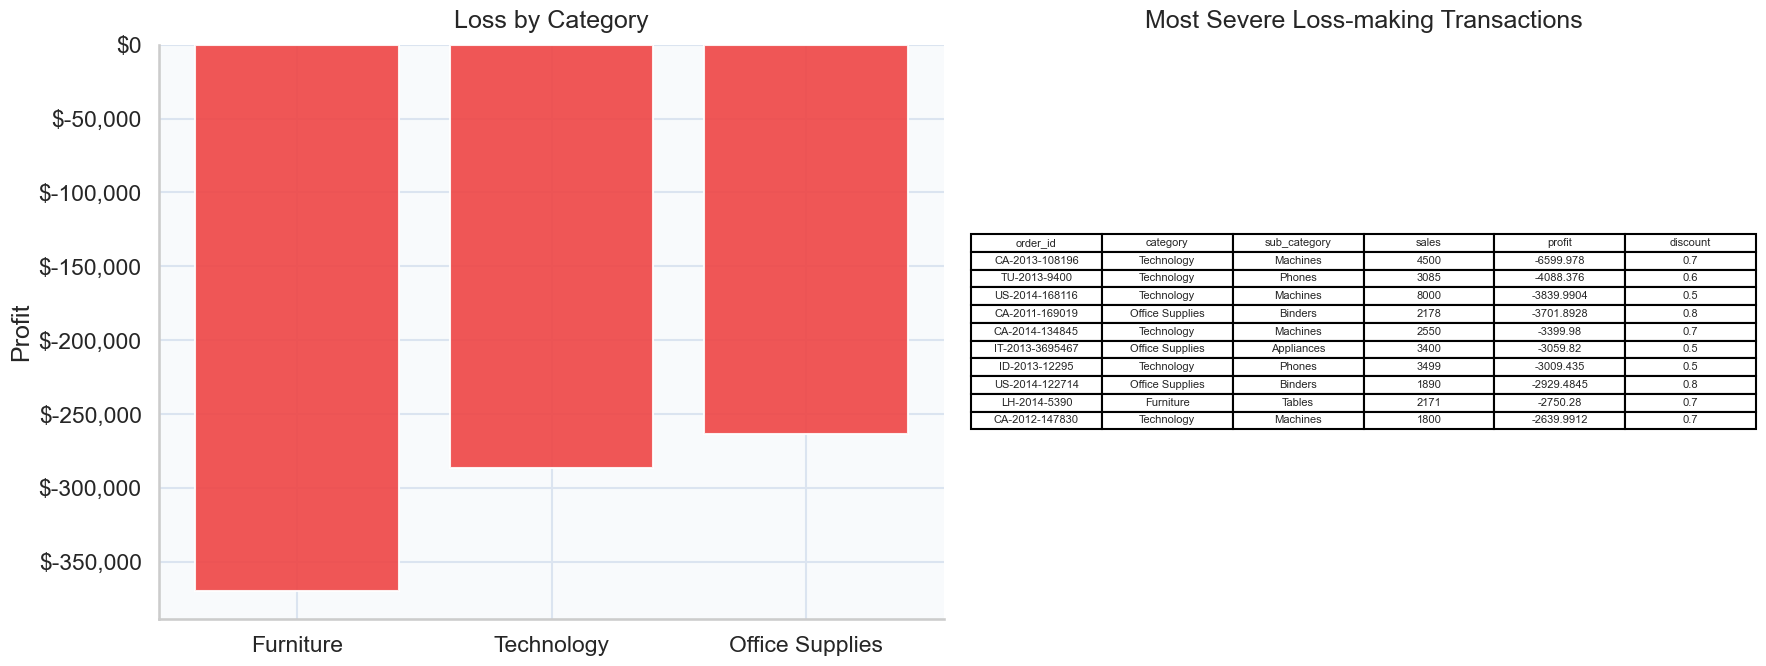

In [7]:

loss_df = df[df["profit"] < 0].copy()
loss_summary = pd.DataFrame(
    {
        "Metric": ["Loss-making Orders", "Total Loss Value", "Average Loss per Order"],
        "Value": [
            f"{loss_df['order_id'].nunique():,}",
            f"${loss_df['profit'].sum():,.0f}",
            f"${loss_df.groupby('order_id')['profit'].sum().mean():,.2f}",
        ],
    }
)

loss_by_category = loss_df.groupby("category")["profit"].sum().sort_values()

display(
    loss_summary.style.hide(axis="index")
    .set_table_styles(
        [
            {"selector": "th", "props": [("background-color", "#fee2e2"), ("color", "#7f1d1d")]},
            {"selector": "td", "props": [("border", "1px solid #fecaca"), ("background-color", "#fff7f7")]},
        ]
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].bar(loss_by_category.index, loss_by_category.values, color="#ef4444", alpha=0.9)
axes[0].set_title("Loss by Category", fontsize=18, pad=12)
axes[0].set_ylabel("Profit")
axes[0].yaxis.set_major_formatter(FuncFormatter(currency))

loss_examples = (
    loss_df.sort_values("profit")
    [["order_id", "category", "sub_category", "sales", "profit", "discount"]]
    .head(10)
)

axes[1].axis("off")
axes[1].table(
    cellText=loss_examples.values,
    colLabels=loss_examples.columns,
    loc="center",
    cellLoc="center",
)
axes[1].set_title("Most Severe Loss-making Transactions", fontsize=18, pad=12)

plt.tight_layout()
plt.show()



> **Insight:** Loss-making transactions are often concentrated rather than random. That is useful news, because concentrated loss patterns can usually be fixed with targeted pricing, discount, shipping, or assortment interventions.



## Customer Dynamics

Customer analysis reveals who drives revenue and how broad the purchasing base really is. Strong customer concentration can be good for scale, but it can also create dependence risk.


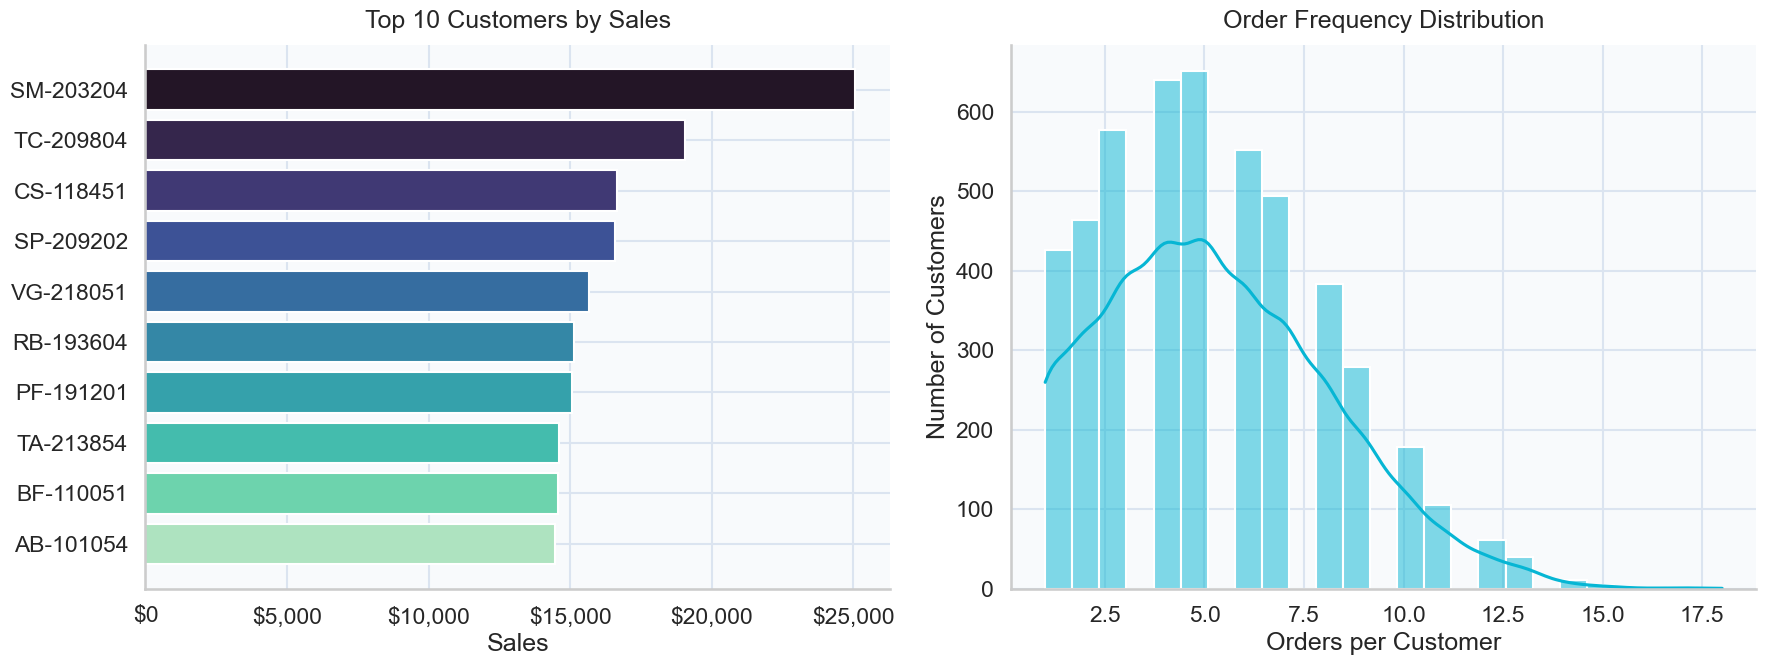

In [8]:

top_customers = df.groupby("customer_id")["sales"].sum().sort_values(ascending=False).head(10)
orders_per_customer = df.groupby("customer_id")["order_id"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top_customers.index, top_customers.values, color=sns.color_palette("mako", 10))
axes[0].invert_yaxis()
axes[0].set_title("Top 10 Customers by Sales", fontsize=18, pad=12)
axes[0].set_xlabel("Sales")
axes[0].xaxis.set_major_formatter(FuncFormatter(currency))

sns.histplot(orders_per_customer, bins=25, kde=True, ax=axes[1], color=COLORS["cyan"])
axes[1].set_title("Order Frequency Distribution", fontsize=18, pad=12)
axes[1].set_xlabel("Orders per Customer")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()



> **Insight:** If a small group of customers accounts for a disproportionate share of revenue, the commercial strategy should balance relationship depth with diversification. The distribution of order frequency helps show whether loyalty is broad-based or narrow.



## Profitability Lens

Margins translate raw revenue into business quality. Looking at margin distribution and average category margin helps reveal whether profitability is stable or overly dependent on a few pockets of the portfolio.


E:\python_temp\ipykernel_23356\760002163.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=margin_by_category.index, y=margin_by_category.values, ax=axes[0], palette="viridis")
E:\python_temp\ipykernel_23356\760002163.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="profit_margin", ax=axes[1], palette="Set2")


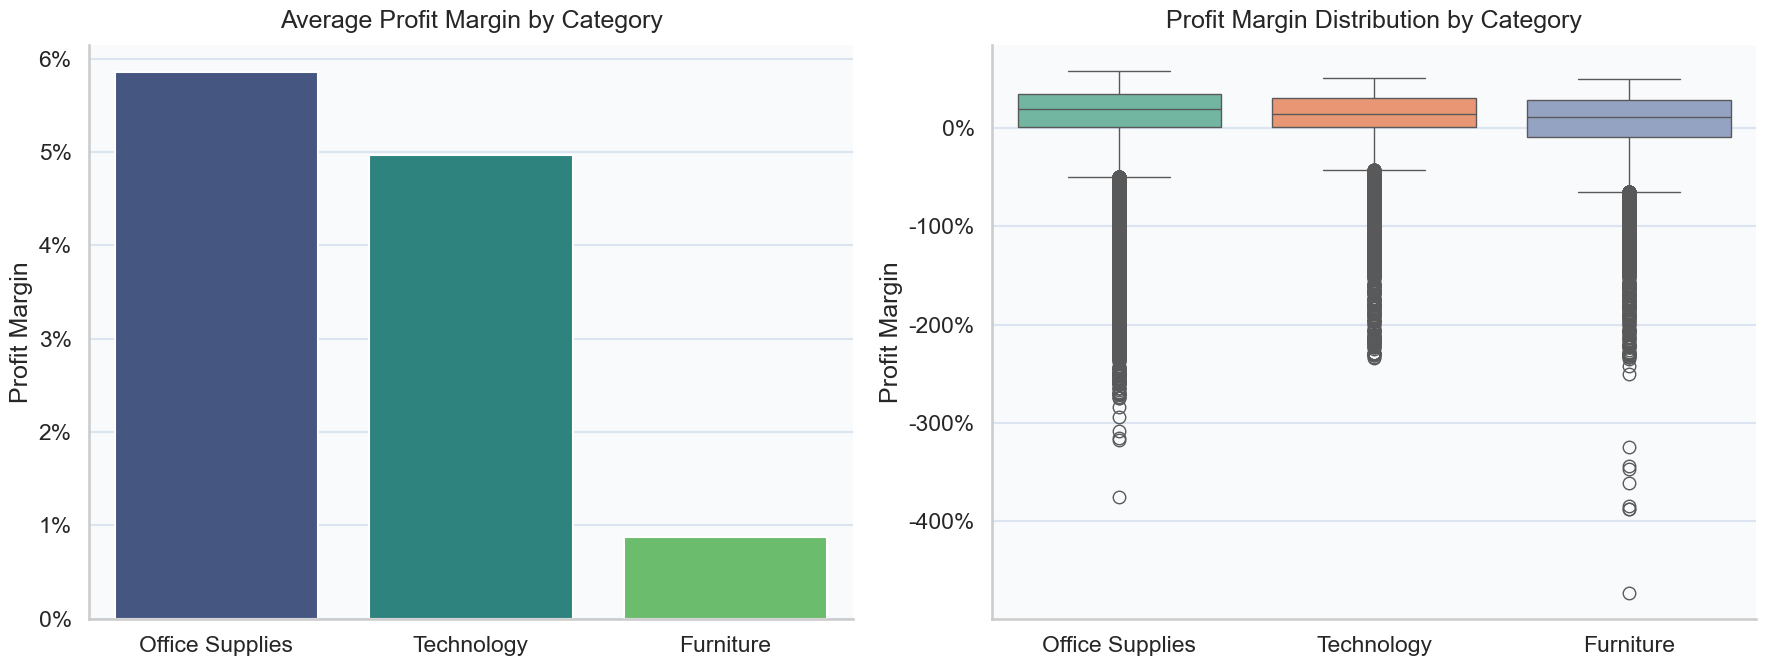

In [9]:

margin_by_category = df.groupby("category")["profit_margin"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x=margin_by_category.index, y=margin_by_category.values, ax=axes[0], palette="viridis")
axes[0].set_title("Average Profit Margin by Category", fontsize=18, pad=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("Profit Margin")
axes[0].yaxis.set_major_formatter(FuncFormatter(percent))

sns.boxplot(data=df, x="category", y="profit_margin", ax=axes[1], palette="Set2")
axes[1].set_title("Profit Margin Distribution by Category", fontsize=18, pad=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("Profit Margin")
axes[1].yaxis.set_major_formatter(FuncFormatter(percent))

plt.tight_layout()
plt.show()



> **Insight:** Mean margin tells us who wins on average, but the boxplot reveals consistency. A category with a respectable average margin may still be operationally risky if its spread includes many deeply negative transactions.



## Segment Performance

The final cut compares customer segments on both scale and efficiency, making it easier to see where to defend share, where to grow, and where to improve economics first.


E:\python_temp\ipykernel_23356\1981323455.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_summary.index, y=segment_summary["sales"], ax=axes[0], palette="Blues")
E:\python_temp\ipykernel_23356\1981323455.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_summary.index, y=segment_summary["profit"], ax=axes[1], palette="Greens")
E:\python_temp\ipykernel_23356\1981323455.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_summary.index, y=segment_summary["profit_margin"], ax=axes[2], palette="rocket")


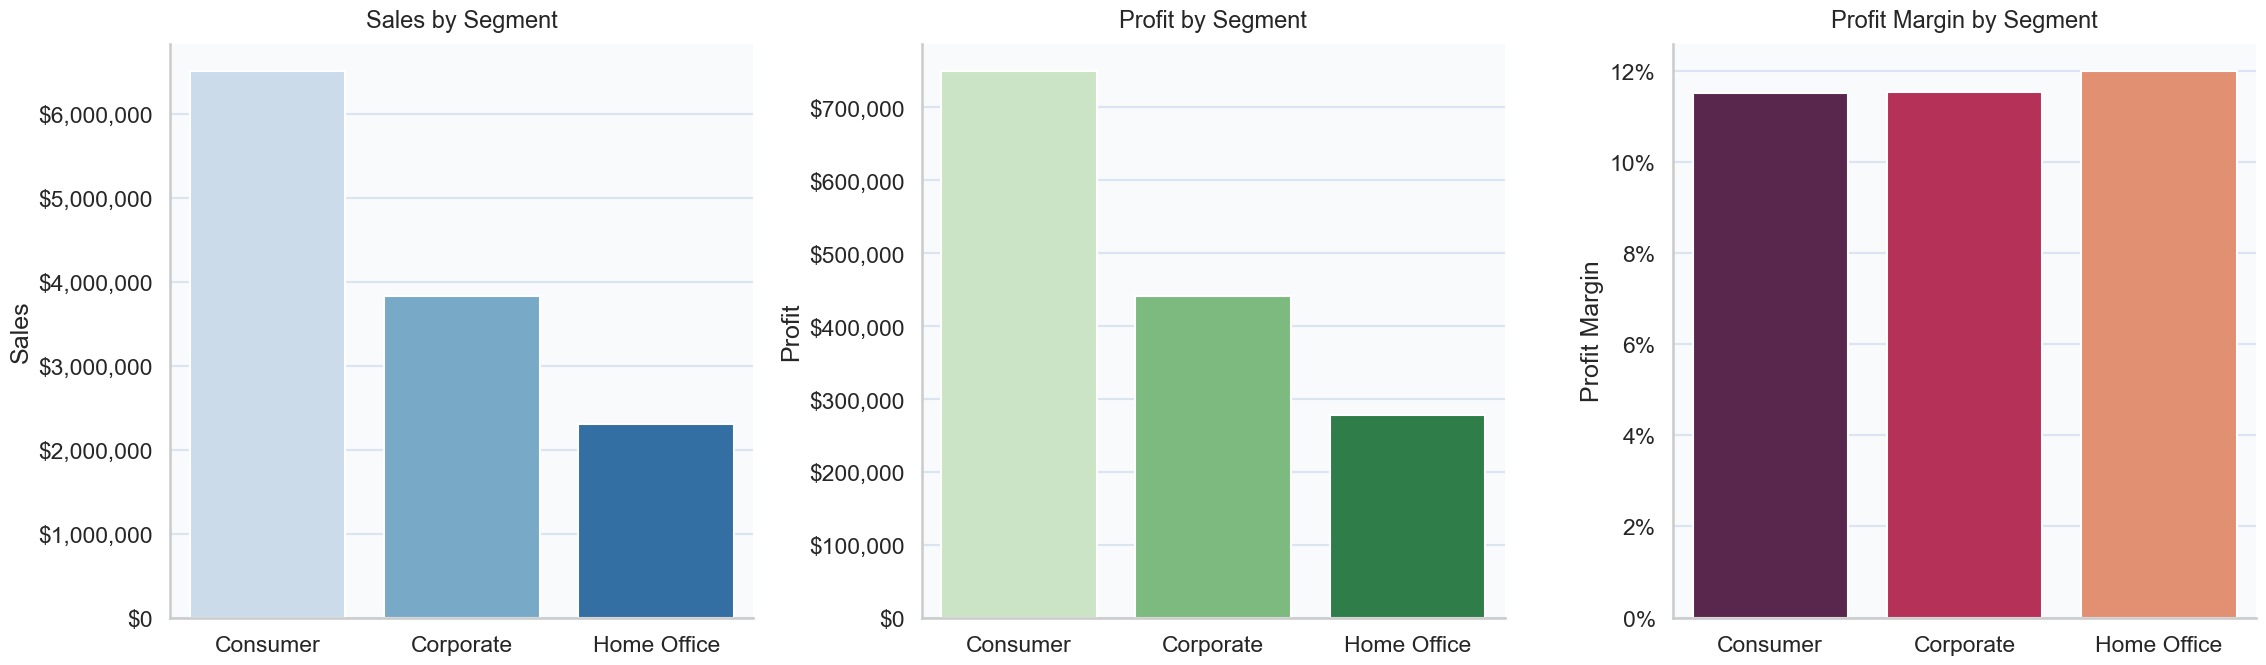

In [10]:

segment_summary = (
    df.groupby("segment")[["sales", "profit"]]
    .sum()
    .assign(profit_margin=lambda x: x["profit"] / x["sales"])
    .sort_values("sales", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(23, 7))

sns.barplot(x=segment_summary.index, y=segment_summary["sales"], ax=axes[0], palette="Blues")
axes[0].set_title("Sales by Segment", fontsize=17, pad=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("Sales")
axes[0].yaxis.set_major_formatter(FuncFormatter(currency))

sns.barplot(x=segment_summary.index, y=segment_summary["profit"], ax=axes[1], palette="Greens")
axes[1].set_title("Profit by Segment", fontsize=17, pad=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("Profit")
axes[1].yaxis.set_major_formatter(FuncFormatter(currency))

sns.barplot(x=segment_summary.index, y=segment_summary["profit_margin"], ax=axes[2], palette="rocket")
axes[2].set_title("Profit Margin by Segment", fontsize=17, pad=12)
axes[2].set_xlabel("")
axes[2].set_ylabel("Profit Margin")
axes[2].yaxis.set_major_formatter(FuncFormatter(percent))

plt.tight_layout()
plt.show()



## Final Takeaways

- Revenue scale is meaningful, but quality varies across time periods, geographies, and segments.
- Product-level and transaction-level analysis show that some volume is expensive and should be optimized rather than expanded.
- Customer and segment concentration should be monitored closely so growth does not become dependent on a narrow set of accounts.
- This notebook is now presentation-friendly: consistent visuals, narrative insights, and a clearer progression from headline KPIs to operational action points.
